
# SINDy Identification — No Magnets, 0.45 g excitation

**Dataset layout. with three columns
(`Non_linear_Force`, `Modal_Displacement`, `Modal_Velocity`) and $N$ rows, where
the **top half is mode 1** and the **bottom half is mode 2**, stacked.

After splitting we reshape into six signals:
$$
M_{nl,1},\; M_{nl,2},\; q_1,\; q_2,\; \dot q_1,\; \dot q_2
$$

**Goal.** Identify sparse symbolic models
$$
M_{nl,k}(t) \;\approx\; \Theta(q_1,q_2,\dot q_1,\dot q_2)\,\Xi_k,\qquad k=1,2
$$
with a polynomial + cross-term library, using STLSQ on the already-computed $M_{nl}$
targets (no re-differentiation).

This notebook processes **only the 4m_04g file**. Duplicate and change
`CSV_PATH` for the other configurations.


In [1]:

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pysindy.feature_library import PolynomialLibrary
from pysindy.optimizers import STLSQ

warnings.filterwarnings('ignore', category=UserWarning, module='pysindy')
plt.rcParams['figure.dpi'] = 110
np.set_printoptions(suppress=True, precision=4)


## 1. Configuration

In [2]:

CSV_PATH = Path('C:\\Users\\rkhadka1\\OneDrive - Lamar University\\Research\\Roshanbeam3\\Nonlinear restoring force\\Nonlinearforce_Data\\Non_linear_force_nm_045g.csv')   # edit path as needed
TAG      = 'nm_045g'                             # used in titles and exports

# Library
POLY_DEGREE  = 3           # 4 magnets => strong nonlinearity, use 5 (try 3 and 7 too)
INCLUDE_BIAS = False       # True only if you expect a constant offset in Mnl

# STLSQ
LAMBDA_GRID     = np.logspace(-3, -0.3, 21)   # 0.001 ... 0.5, spans the useful range
DEFAULT_LAMBDA  = 5e-2     # override after inspecting the Pareto table
ALPHA_RIDGE     = 5e-2     # ridge stabilizes the inner least-squares; raise if coeffs explode



## 2. Load and split the CSV into mode 1 and mode 2

Top half is mode 1, bottom half is mode 2. After splitting we assemble:

- `X = [q1, q2, qd1, qd2]` of shape $(N_{\text{half}},\,4)$ — shared feature matrix
- `Y = [Mnl1, Mnl2]` of shape $(N_{\text{half}},\,2)$ — the two targets


In [3]:

df = pd.read_csv(CSV_PATH)
assert set(df.columns) >= {'Non_linear_Force', 'Modal_Displacement', 'Modal_Velocity'}, \
    f'Unexpected columns: {df.columns.tolist()}'
assert len(df) % 2 == 0, f'Row count {len(df)} is not even; cannot split in half.'

half = len(df) // 2
top  = df.iloc[:half].reset_index(drop=True)     # mode 1
bot  = df.iloc[half:].reset_index(drop=True)     # mode 2

Mnl1 = top['Non_linear_Force'].to_numpy()
q1   = top['Modal_Displacement'].to_numpy()
qd1  = top['Modal_Velocity'].to_numpy()

Mnl2 = bot['Non_linear_Force'].to_numpy()
q2   = bot['Modal_Displacement'].to_numpy()
qd2  = bot['Modal_Velocity'].to_numpy()

X = np.column_stack([q1, q2, qd1, qd2])          # features
Y = np.column_stack([Mnl1, Mnl2])                # targets

print(f'N per mode = {half:,}')
print(f'q1  range [{q1.min():+.3e}, {q1.max():+.3e}]   std = {q1.std():.3e}')
print(f'q2  range [{q2.min():+.3e}, {q2.max():+.3e}]   std = {q2.std():.3e}')
print(f'qd1 range [{qd1.min():+.3e}, {qd1.max():+.3e}]   std = {qd1.std():.3e}')
print(f'qd2 range [{qd2.min():+.3e}, {qd2.max():+.3e}]   std = {qd2.std():.3e}')
print(f'Mnl1 range [{Mnl1.min():+.3e}, {Mnl1.max():+.3e}]   std = {Mnl1.std():.3e}')
print(f'Mnl2 range [{Mnl2.min():+.3e}, {Mnl2.max():+.3e}]   std = {Mnl2.std():.3e}')


N per mode = 40,961
q1  range [-7.108e-04, +6.946e-04]   std = 4.992e-04
q2  range [-5.006e-04, +5.222e-04]   std = 3.592e-04
qd1 range [-1.600e-01, +1.581e-01]   std = 1.113e-01
qd2 range [-1.118e-01, +1.123e-01]   std = 8.014e-02
Mnl1 range [-2.571e+00, +1.978e+00]   std = 1.196e+00
Mnl2 range [-9.981e+02, +9.599e+02]   std = 6.882e+02


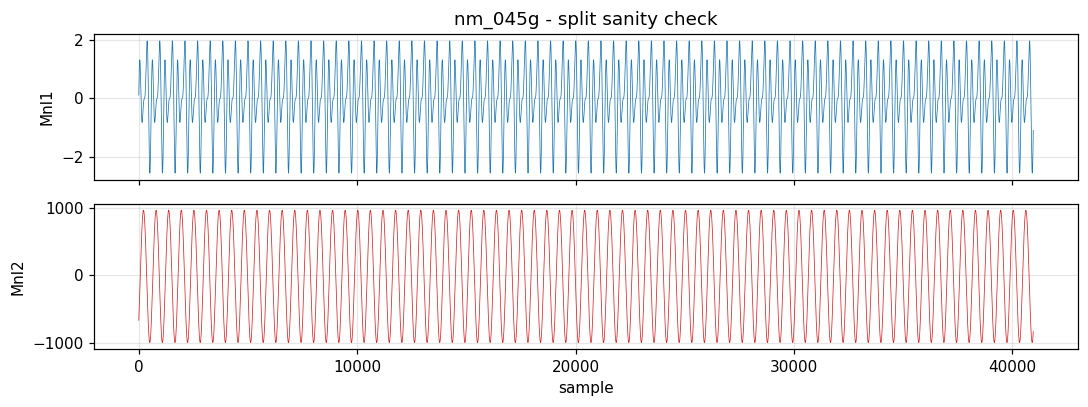

In [4]:

# Quick visual check of the split
fig, ax = plt.subplots(2, 1, figsize=(10, 3.8), sharex=True)
ax[0].plot(Mnl1, lw=0.5, color='C0'); ax[0].set_ylabel('Mnl1')
ax[0].set_title(f'{TAG} - split sanity check')
ax[1].plot(Mnl2, lw=0.5, color='C3'); ax[1].set_ylabel('Mnl2'); ax[1].set_xlabel('sample')
for a in ax: a.grid(alpha=0.3)
plt.tight_layout(); plt.show()



## 3. Feature library and custom-target SINDy

Because $M_{nl}$ is **already computed** (not a time derivative of a state), we skip
`pysindy.SINDy`'s top-level wrapper — which would re-differentiate your
Fourier-cleaned signals — and run STLSQ directly on $\Theta\Xi \approx M_{nl}$.

**Dual normalization.** Library columns span ~20 orders of magnitude at degree 5
($q \sim 10^{-4}$, $q^5 \sim 10^{-20}$), and the two modes have target magnitudes
that differ by $\sim 10^3$ ($|M_{nl,1}|\lesssim 3$ vs $|M_{nl,2}|\lesssim 1600$). Without
normalizing **both** sides the threshold $\lambda$ is effectively unit-bearing:
the same numerical value means something completely different for the two modes
and for different polynomial degrees. We normalize each column of $\Theta$ to unit
$\ell_2$-norm **and** the target $y$ to unit $\ell_2$-norm, run STLSQ on the
resulting dimensionless system, and rescale coefficients back to physical units.
After this, the same `LAMBDA_GRID` is meaningful across modes and configurations.


In [5]:

FEATURE_VARS = ['q1', 'q2', 'qd1', 'qd2']


def build_library(degree=POLY_DEGREE, include_bias=INCLUDE_BIAS):
    return PolynomialLibrary(
        degree=degree,
        include_bias=include_bias,
        include_interaction=True,
    )


def fit_custom_target(X, y, lib, threshold, alpha=ALPHA_RIDGE, max_iter=200):
    # Normalize BOTH library columns and target before STLSQ, then rescale
    # coefficients back to physical units.  This is critical:
    #  * column scales alone leave the threshold comparing against coefficients
    #    whose magnitude depends on ||y||, which varies ~1e3x between modes.
    #  * dual normalization puts the threshold in dimensionless units so the
    #    same lambda grid is meaningful for both Mnl1 and Mnl2.
    lib.fit(X)
    # np.asarray strips pysindy's AxesArray wrapper so plain numpy matmul works.
    Theta = np.asarray(lib.transform(X))
    names = lib.get_feature_names(FEATURE_VARS)

    col_scales = np.linalg.norm(Theta, axis=0) + 1e-30
    y_scale    = np.linalg.norm(y) + 1e-30
    Theta_n    = Theta / col_scales
    y_n        = y / y_scale

    opt = STLSQ(threshold=threshold, alpha=alpha, max_iter=max_iter)
    opt.fit(Theta_n, y_n.reshape(-1, 1))
    xi_n = opt.coef_.ravel()

    xi = xi_n * y_scale / col_scales     # back to raw physical units
    return xi, names, Theta


def format_equation(xi, names, lhs='Mnl', tol=1e-12):
    terms = [(c, n) for c, n in zip(xi, names) if abs(c) > tol]
    terms.sort(key=lambda t: -abs(t[0]))
    if not terms:
        return f'{lhs} = 0'
    rhs = '  +  '.join(f'{c:+.5g} * {n}' for c, n in terms)
    return f'{lhs} = {rhs}'


def error_metrics(y, y_hat):
    resid = y - y_hat
    sse   = float(np.sum(resid ** 2))
    sst   = float(np.sum((y - y.mean()) ** 2))
    return {
        'RMSE'    : float(np.sqrt(np.mean(resid ** 2))),
        'MAE'     : float(np.mean(np.abs(resid))),
        'MaxAbs'  : float(np.max(np.abs(resid))),
        'R2'      : 1.0 - sse / sst if sst > 0 else float('nan'),
        'RMSE/std': float(np.sqrt(np.mean(resid ** 2)) / (y.std() + 1e-30)),
    }



## 4. Pareto sweep over the sparsity threshold

For each mode we sweep $\lambda$ and record (# retained terms, RMSE, R², RMSE/std).
Pick the elbow — smallest model that doesn't materially hurt fit.


In [6]:

def pareto_sweep(X, y, lib, thresholds):
    rows = []
    for lam in thresholds:
        xi, _, Theta = fit_custom_target(X, y, lib, threshold=lam)
        yhat = Theta @ xi
        m    = error_metrics(y, yhat)
        rows.append((lam, int(np.sum(np.abs(xi) > 0)), m['RMSE'], m['R2'], m['RMSE/std']))
    return pd.DataFrame(rows, columns=['lambda', 'n_terms', 'RMSE', 'R2', 'RMSE/std'])


sweep1 = pareto_sweep(X, Mnl1, build_library(), LAMBDA_GRID)
sweep2 = pareto_sweep(X, Mnl2, build_library(), LAMBDA_GRID)

print('--- Mode 1 Pareto ---')
print(sweep1.to_string(index=False,
      formatters={'lambda':'{:.2e}'.format,'RMSE':'{:.3e}'.format,
                  'R2':'{:+.4f}'.format,'RMSE/std':'{:.3e}'.format}))
print()
print('--- Mode 2 Pareto ---')
print(sweep2.to_string(index=False,
      formatters={'lambda':'{:.2e}'.format,'RMSE':'{:.3e}'.format,
                  'R2':'{:+.4f}'.format,'RMSE/std':'{:.3e}'.format}))


--- Mode 1 Pareto ---
  lambda  n_terms      RMSE      R2  RMSE/std
1.00e-03       34 2.978e-13 +1.0000 2.490e-13
1.36e-03       32 2.978e-13 +1.0000 2.491e-13
1.86e-03       31 2.978e-13 +1.0000 2.491e-13
2.54e-03       31 2.978e-13 +1.0000 2.491e-13
3.47e-03       31 2.978e-13 +1.0000 2.491e-13
4.73e-03       31 2.978e-13 +1.0000 2.491e-13
6.46e-03       31 2.978e-13 +1.0000 2.491e-13
8.81e-03       30 2.978e-13 +1.0000 2.491e-13
1.20e-02       29 2.977e-13 +1.0000 2.490e-13
1.64e-02       29 2.977e-13 +1.0000 2.490e-13
2.24e-02       28 2.972e-13 +1.0000 2.485e-13
3.05e-02       22 8.418e-12 +1.0000 7.040e-12
4.17e-02       17 2.192e-09 +1.0000 1.833e-09
5.69e-02       16 1.122e-07 +1.0000 9.381e-08
7.76e-02       11 3.239e-03 +1.0000 2.709e-03
1.06e-01        7 1.570e-01 +0.9828 1.313e-01
1.45e-01        4 5.920e-01 +0.7549 4.951e-01
1.97e-01        3 6.591e-01 +0.6962 5.512e-01
2.69e-01        0 1.196e+00 -0.0002 1.000e+00
3.67e-01        0 1.196e+00 -0.0002 1.000e+00
5.01e-01    

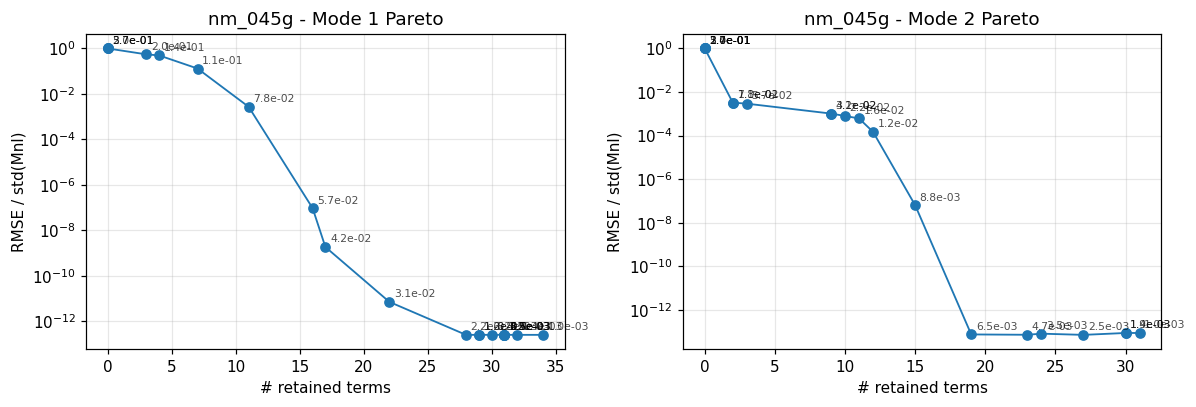

In [7]:

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for a, sw, title in zip(ax, (sweep1, sweep2), ('Mode 1', 'Mode 2')):
    a.plot(sw['n_terms'], sw['RMSE/std'], 'o-', lw=1.2)
    for _, r in sw.iterrows():
        a.annotate(f"{r['lambda']:.1e}", (r['n_terms'], r['RMSE/std']),
                   fontsize=7, alpha=0.7, xytext=(3, 3), textcoords='offset points')
    a.set_xlabel('# retained terms'); a.set_ylabel('RMSE / std(Mnl)')
    a.set_yscale('log'); a.set_title(f'{TAG} - {title} Pareto')
    a.grid(alpha=0.3)
plt.tight_layout(); plt.show()



## 5. Final fit at the chosen threshold

Adjust `LAMBDA_M1` and `LAMBDA_M2` below based on the Pareto plots above,
then re-run this cell.


In [8]:

LAMBDA_M1 = DEFAULT_LAMBDA
LAMBDA_M2 = DEFAULT_LAMBDA

xi1, names, Theta1 = fit_custom_target(X, Mnl1, build_library(), threshold=LAMBDA_M1)
xi2, _,     Theta2 = fit_custom_target(X, Mnl2, build_library(), threshold=LAMBDA_M2)

Mnl1_hat = Theta1 @ xi1
Mnl2_hat = Theta2 @ xi2

err1 = error_metrics(Mnl1, Mnl1_hat)
err2 = error_metrics(Mnl2, Mnl2_hat)

print(f'=== {TAG} - Mode 1  (lambda = {LAMBDA_M1}) ===')
print(format_equation(xi1, names, lhs='Mnl1'))
print(f'  metrics: {err1}')
print()
print(f'=== {TAG} - Mode 2  (lambda = {LAMBDA_M2}) ===')
print(format_equation(xi2, names, lhs='Mnl2'))
print(f'  metrics: {err2}')


=== nm_045g - Mode 1  (lambda = 0.05) ===
Mnl1 = -4.8277e+10 * q1 q2^2  +  +1.502e+10 * q1^2 q2  +  -3.6891e+09 * q1^3  +  +3.9282e+08 * q1 q2  +  -2.2945e+08 * q1^2  +  -1.0944e+08 * q2^2  +  -4.1151e+05 * q2 qd1 qd2  +  -1.3789e+05 * q2 qd2^2  +  +60045 * q1 qd1 qd2  +  +38108 * q2 qd1^2  +  -36500 * q1 qd1  +  +21161 * q1 qd2^2  +  +3427.5 * q1  +  +2273.4 * qd1 qd2  +  -1619.6 * qd1^2  +  +170.73 * qd2^2
  metrics: {'RMSE': 8.04774313944598e-08, 'MAE': 7.19356880873474e-08, 'MaxAbs': 1.3008759225385802e-07, 'R2': 0.9999999999999954, 'RMSE/std': 6.730501512609105e-08}

=== nm_045g - Mode 2  (lambda = 0.05) ===
Mnl2 = +2.1799e+11 * q2^3  +  -1.2932e+11 * q1 q2^2  +  -2.0015e+06 * q2  +  +56180 * q1
  metrics: {'RMSE': 1.9670684722642493, 'MAE': 1.7401321105400054, 'MaxAbs': 3.355248827215318, 'R2': 0.9999918299031714, 'RMSE/std': 0.0028583381235656176}


## 6. Coefficient table and bar chart

In [9]:

coef_df = pd.DataFrame({
    'term': names,
    'Mnl1_coef': xi1,
    'Mnl2_coef': xi2,
})
coef_df = coef_df[(coef_df['Mnl1_coef'].abs() > 0) | (coef_df['Mnl2_coef'].abs() > 0)]
coef_df = coef_df.reindex(coef_df[['Mnl1_coef', 'Mnl2_coef']].abs().max(axis=1)
                          .sort_values(ascending=False).index).reset_index(drop=True)
print(coef_df.to_string(index=False,
      formatters={'Mnl1_coef':'{:+.4e}'.format, 'Mnl2_coef':'{:+.4e}'.format}))


      term   Mnl1_coef   Mnl2_coef
      q2^3 +0.0000e+00 +2.1799e+11
   q1 q2^2 -4.8277e+10 -1.2932e+11
   q1^2 q2 +1.5020e+10 +0.0000e+00
      q1^3 -3.6891e+09 +0.0000e+00
     q1 q2 +3.9282e+08 +0.0000e+00
      q1^2 -2.2945e+08 +0.0000e+00
      q2^2 -1.0944e+08 +0.0000e+00
        q2 +0.0000e+00 -2.0015e+06
q2 qd1 qd2 -4.1151e+05 +0.0000e+00
  q2 qd2^2 -1.3789e+05 +0.0000e+00
q1 qd1 qd2 +6.0045e+04 +0.0000e+00
        q1 +3.4275e+03 +5.6180e+04
  q2 qd1^2 +3.8108e+04 +0.0000e+00
    q1 qd1 -3.6500e+04 +0.0000e+00
  q1 qd2^2 +2.1161e+04 +0.0000e+00
   qd1 qd2 +2.2734e+03 +0.0000e+00
     qd1^2 -1.6196e+03 +0.0000e+00
     qd2^2 +1.7073e+02 +0.0000e+00


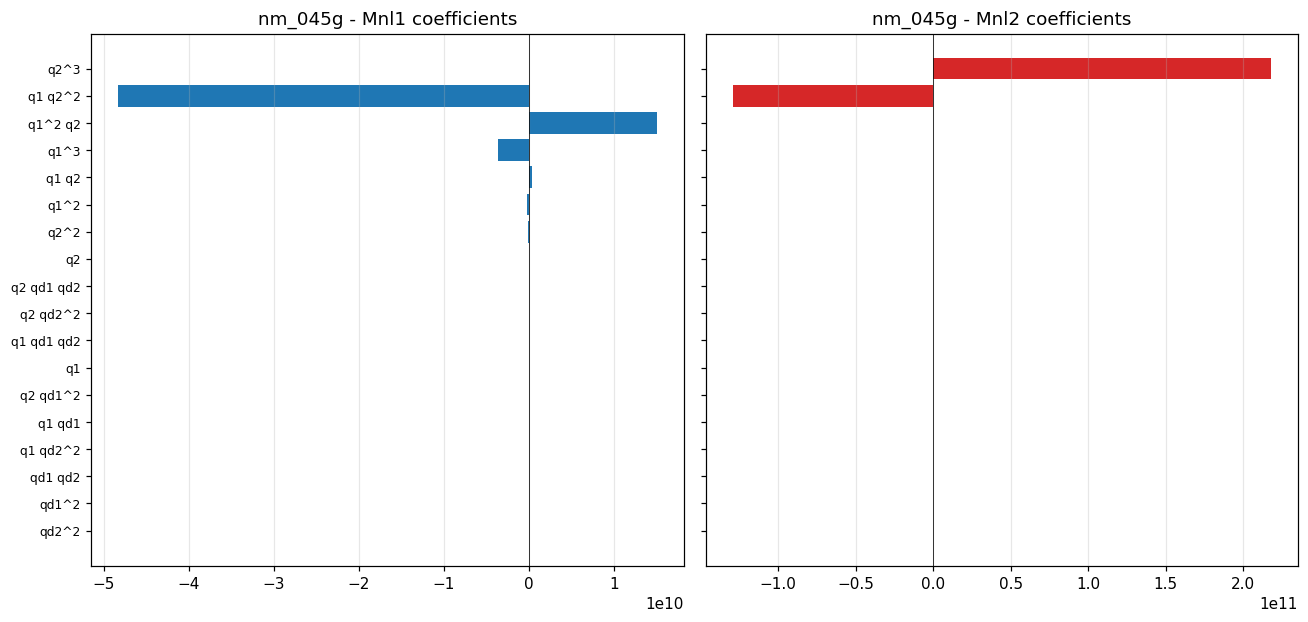

In [10]:

fig, ax = plt.subplots(1, 2, figsize=(12, max(3, 0.32 * len(coef_df))), sharey=True)
y_pos = np.arange(len(coef_df))
ax[0].barh(y_pos, coef_df['Mnl1_coef'], color='C0')
ax[0].set_yticks(y_pos); ax[0].set_yticklabels(coef_df['term'], fontsize=8)
ax[0].set_title(f'{TAG} - Mnl1 coefficients'); ax[0].axvline(0, color='k', lw=0.5)
ax[0].invert_yaxis(); ax[0].grid(alpha=0.3, axis='x')

ax[1].barh(y_pos, coef_df['Mnl2_coef'], color='C3')
ax[1].set_title(f'{TAG} - Mnl2 coefficients'); ax[1].axvline(0, color='k', lw=0.5)
ax[1].grid(alpha=0.3, axis='x')
plt.tight_layout(); plt.show()


## 7. Diagnostic plots - reconstruction, residuals, parity, phase portrait

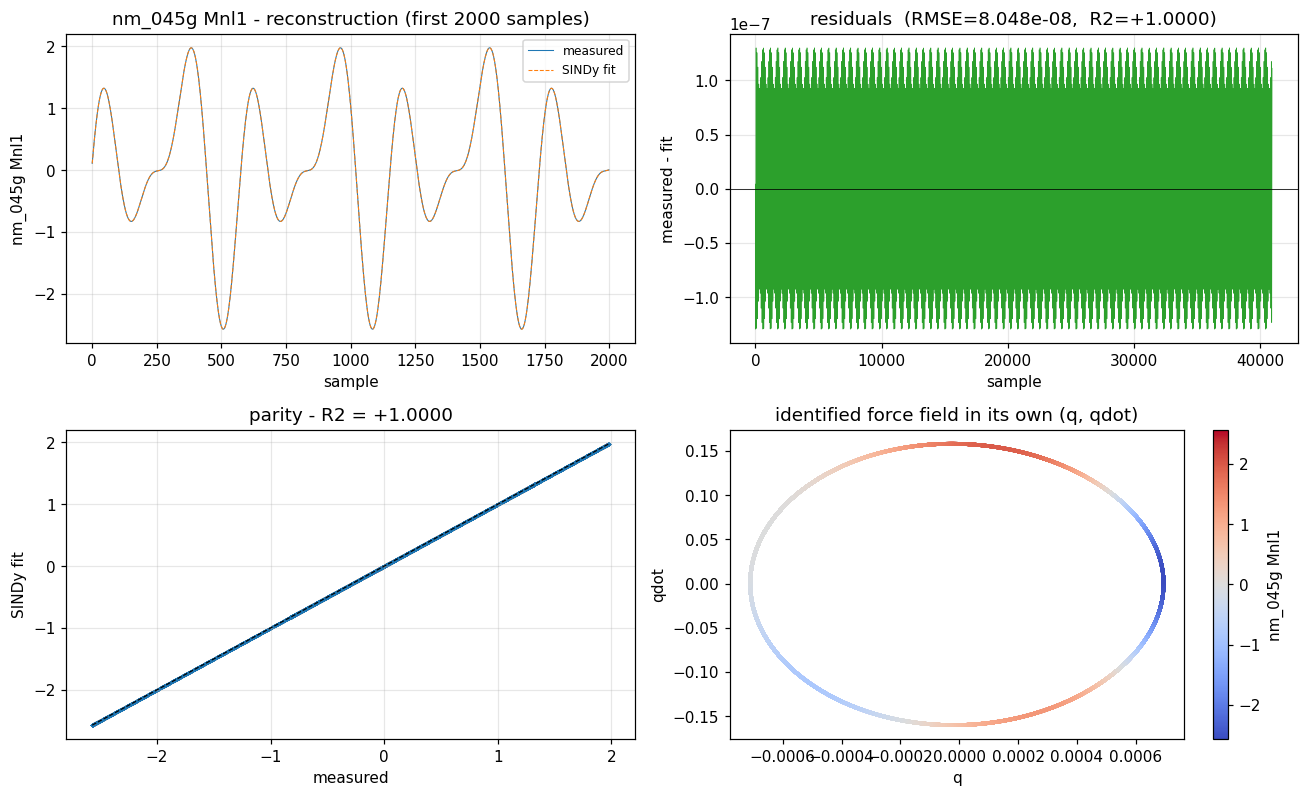

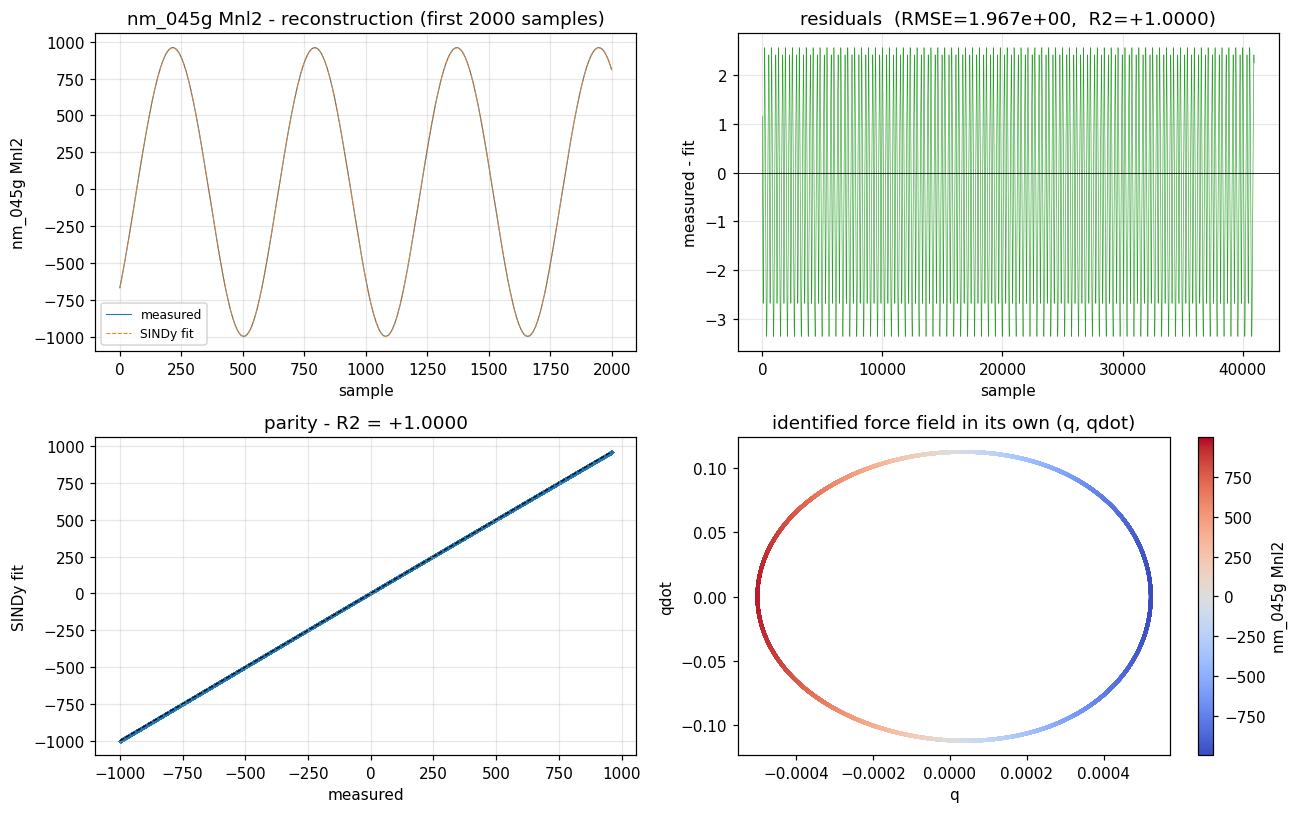

In [11]:

def plot_diagnostics(tag_suffix, y, y_hat, q_a, qd_a, err, n_show=2000):
    resid = y - y_hat
    fig, ax = plt.subplots(2, 2, figsize=(12, 7.5))

    # (a) time overlay
    n = min(n_show, len(y))
    ax[0, 0].plot(y[:n], lw=0.7, label='measured')
    ax[0, 0].plot(y_hat[:n], lw=0.7, ls='--', label='SINDy fit')
    ax[0, 0].set_title(f'{tag_suffix} - reconstruction (first {n} samples)')
    ax[0, 0].set_xlabel('sample'); ax[0, 0].set_ylabel(tag_suffix)
    ax[0, 0].legend(fontsize=8); ax[0, 0].grid(alpha=0.3)

    # (b) residuals over time
    ax[0, 1].plot(resid, lw=0.4, color='C2')
    ax[0, 1].axhline(0, color='k', lw=0.5)
    ax[0, 1].set_title(f"residuals  (RMSE={err['RMSE']:.3e},  R2={err['R2']:+.4f})")
    ax[0, 1].set_xlabel('sample'); ax[0, 1].set_ylabel('measured - fit')
    ax[0, 1].grid(alpha=0.3)

    # (c) parity
    ax[1, 0].scatter(y, y_hat, s=1, alpha=0.3)
    lim = [min(y.min(), y_hat.min()), max(y.max(), y_hat.max())]
    ax[1, 0].plot(lim, lim, 'k--', lw=0.8)
    ax[1, 0].set_xlabel('measured'); ax[1, 0].set_ylabel('SINDy fit')
    ax[1, 0].set_title(f"parity - R2 = {err['R2']:+.4f}")
    ax[1, 0].grid(alpha=0.3)

    # (d) phase portrait coloured by fitted force
    sc = ax[1, 1].scatter(q_a, qd_a, c=y_hat, s=2, cmap='coolwarm',
                          vmin=-np.max(np.abs(y_hat)), vmax=+np.max(np.abs(y_hat)))
    ax[1, 1].set_xlabel('q'); ax[1, 1].set_ylabel('qdot')
    ax[1, 1].set_title('identified force field in its own (q, qdot)')
    plt.colorbar(sc, ax=ax[1, 1], label=tag_suffix)

    plt.tight_layout()
    plt.show()


plot_diagnostics(f'{TAG} Mnl1', Mnl1, Mnl1_hat, q1, qd1, err1)
plot_diagnostics(f'{TAG} Mnl2', Mnl2, Mnl2_hat, q2, qd2, err2)


## 8. Export equations and error metrics

In [12]:

out_coef = Path(f'sindy_coefficients_{TAG}.csv')
out_err  = Path(f'sindy_errors_{TAG}.csv')

coef_df.to_csv(out_coef, index=False)

err_df = pd.DataFrame([
    {'mode': 'Mnl1', 'lambda': LAMBDA_M1, **err1},
    {'mode': 'Mnl2', 'lambda': LAMBDA_M2, **err2},
])
err_df.to_csv(out_err, index=False)

print('Wrote:', out_coef.resolve())
print('Wrote:', out_err.resolve())
err_df


Wrote: C:\Users\rkhadka1\OneDrive - Lamar University\Research\Roshanbeam3\Algorithm\sindy_coefficients_nm_045g.csv
Wrote: C:\Users\rkhadka1\OneDrive - Lamar University\Research\Roshanbeam3\Algorithm\sindy_errors_nm_045g.csv


,mode,lambda,RMSE,MAE,MaxAbs,R2,RMSE/std
0,Mnl1,0.05,8.047743e-08,7.193569e-08,1.300876e-07,1.000000,6.730502e-08
1,Mnl2,0.05,1.967068e+00,1.740132e+00,3.355249e+00,0.999992,2.858338e-03


--- Linear coefficients that were removed ---
  Mnl1: {'q1': np.float64(3427.5215915968774)}
  Mnl2: {'q1': np.float64(56180.30374475548), 'q2': np.float64(-2001545.08328412)}

--- Purely nonlinear part of SINDy prediction ---
  Mnl1_nl_pred range [-4.949e+00, +2.369e+00]   std = 2.294e+00
  Mnl2_nl_pred range [-4.466e+00, +6.713e+00]   std = 3.033e+00


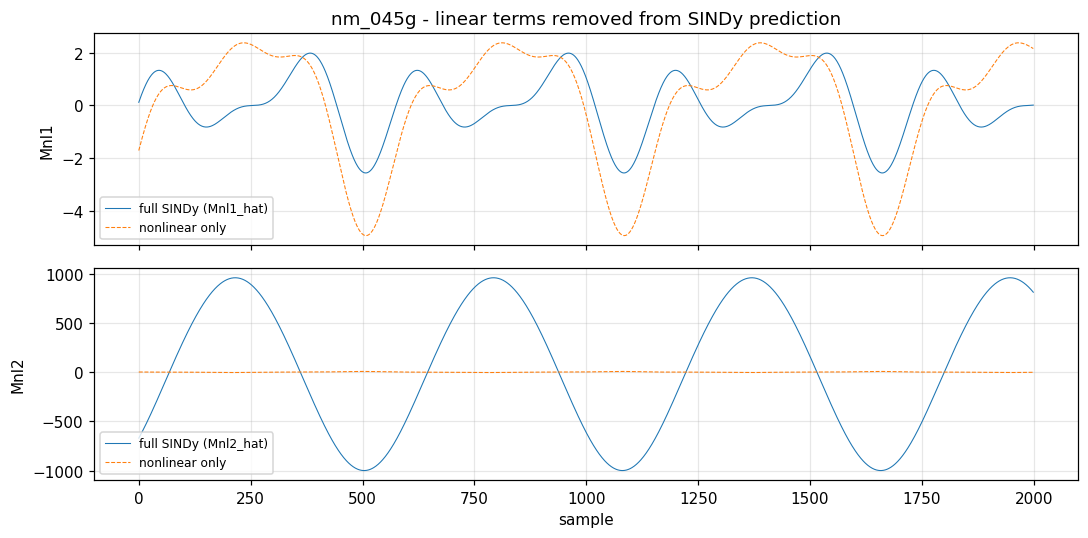

In [13]:
# ---------------------------------------------------------------
#  Strip linear terms (q1, q2, qd1, qd2) from the SINDy prediction
# ---------------------------------------------------------------
LINEAR_TERMS = {'q1', 'q2', 'qd1', 'qd2'}

def split_linear_nonlinear(xi, names, Theta):
    """Return (Mnl_linear_part, Mnl_nonlinear_part, xi_nonlinear)."""
    xi_lin = np.array([c if n in LINEAR_TERMS else 0.0
                       for c, n in zip(xi, names)])
    xi_nl  = np.array([0.0 if n in LINEAR_TERMS else c
                       for c, n in zip(xi, names)])
    return Theta @ xi_lin, Theta @ xi_nl, xi_nl


Mnl1_lin, Mnl1_nl_pred, xi1_nl = split_linear_nonlinear(xi1, names, Theta1)
Mnl2_lin, Mnl2_nl_pred, xi2_nl = split_linear_nonlinear(xi2, names, Theta2)

print('--- Linear coefficients that were removed ---')
for tag, xi in [('Mnl1', xi1), ('Mnl2', xi2)]:
    lin = {n: c for c, n in zip(xi, names) if n in LINEAR_TERMS and abs(c) > 0}
    print(f'  {tag}: {lin if lin else "(none)"}')

print('\n--- Purely nonlinear part of SINDy prediction ---')
print(f'  Mnl1_nl_pred range [{Mnl1_nl_pred.min():+.3e}, {Mnl1_nl_pred.max():+.3e}]'
      f'   std = {Mnl1_nl_pred.std():.3e}')
print(f'  Mnl2_nl_pred range [{Mnl2_nl_pred.min():+.3e}, {Mnl2_nl_pred.max():+.3e}]'
      f'   std = {Mnl2_nl_pred.std():.3e}')

# Quick visual comparison: full prediction vs nonlinear-only prediction
fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
n = min(2000, len(Mnl1_hat))
ax[0].plot(Mnl1_hat[:n],     lw=0.7, label='full SINDy (Mnl1_hat)')
ax[0].plot(Mnl1_nl_pred[:n], lw=0.7, ls='--', label='nonlinear only')
ax[0].set_ylabel('Mnl1'); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
ax[0].set_title(f'{TAG} - linear terms removed from SINDy prediction')

ax[1].plot(Mnl2_hat[:n],     lw=0.7, label='full SINDy (Mnl2_hat)')
ax[1].plot(Mnl2_nl_pred[:n], lw=0.7, ls='--', label='nonlinear only')
ax[1].set_ylabel('Mnl2'); ax[1].set_xlabel('sample')
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

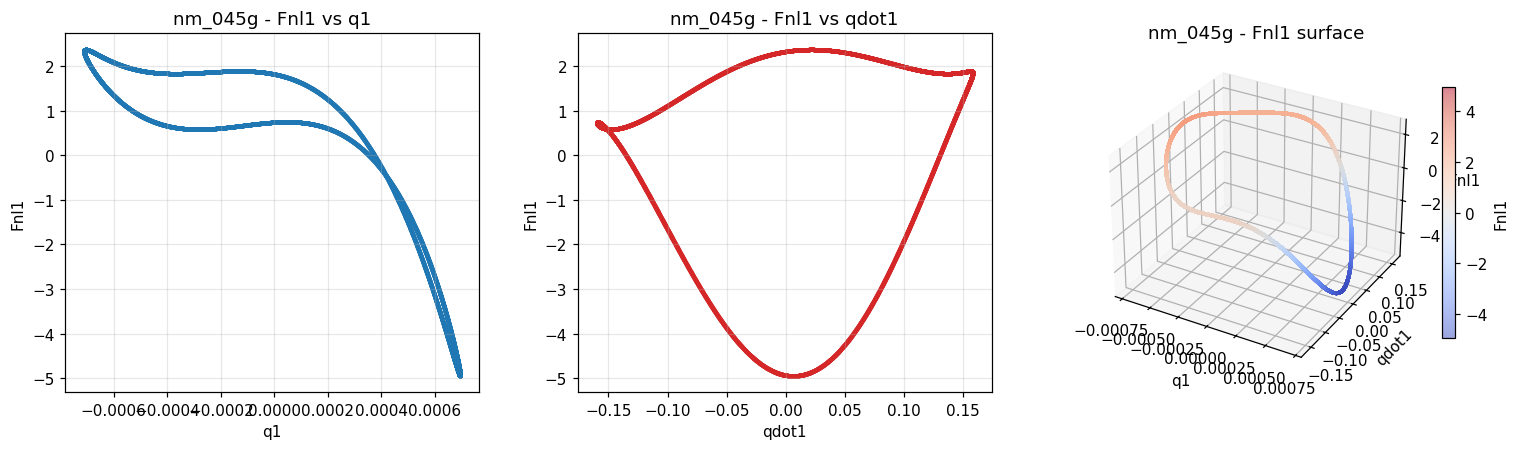

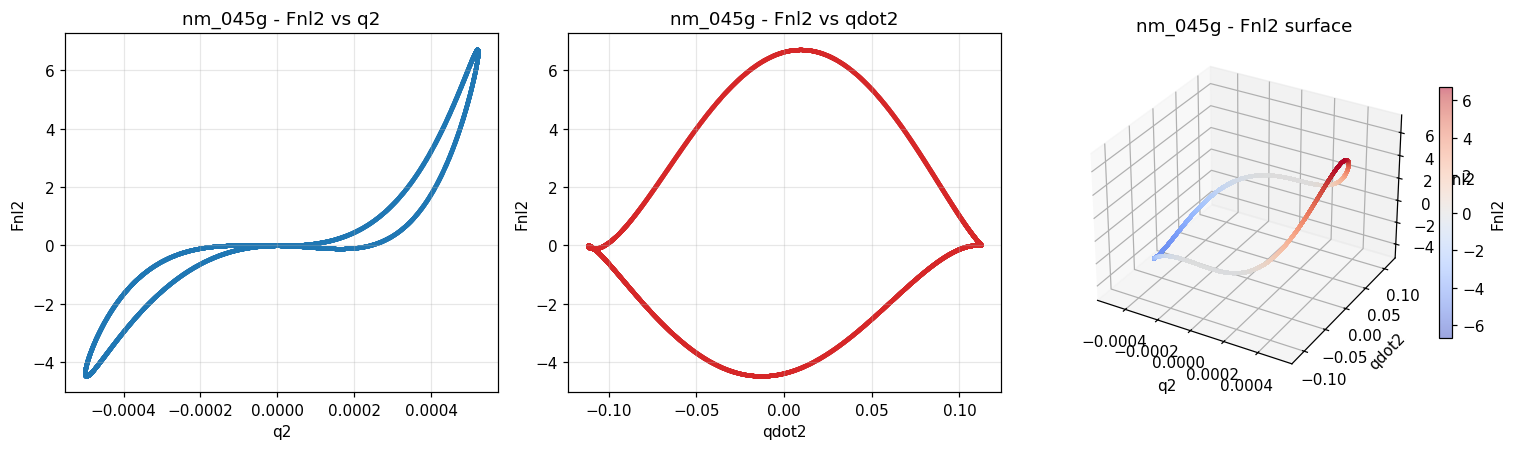

In [14]:
# ---------------------------------------------------------------
#  Plot the purely nonlinear force against the modal coordinates
# ---------------------------------------------------------------
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3d projection)

def plot_fnl_vs_states(fnl, q, qd, mode_label, tag=TAG):
    fig = plt.figure(figsize=(14, 4.2))

    # (a) Fnl vs q
    ax1 = fig.add_subplot(1, 3, 1)
    ax1.scatter(q, fnl, s=2, alpha=0.35, color='C0')
    ax1.set_xlabel(f'q{mode_label}')
    ax1.set_ylabel(f'Fnl{mode_label}')
    ax1.set_title(f'{tag} - Fnl{mode_label} vs q{mode_label}')
    ax1.grid(alpha=0.3)

    # (b) Fnl vs qdot
    ax2 = fig.add_subplot(1, 3, 2)
    ax2.scatter(qd, fnl, s=2, alpha=0.35, color='C3')
    ax2.set_xlabel(f'qdot{mode_label}')
    ax2.set_ylabel(f'Fnl{mode_label}')
    ax2.set_title(f'{tag} - Fnl{mode_label} vs qdot{mode_label}')
    ax2.grid(alpha=0.3)

    # (c) Fnl vs (q, qdot) - 3D scatter coloured by Fnl
    ax3 = fig.add_subplot(1, 3, 3, projection='3d')
    sc = ax3.scatter(q, qd, fnl, c=fnl, s=2, alpha=0.5, cmap='coolwarm',
                     vmin=-np.max(np.abs(fnl)), vmax=+np.max(np.abs(fnl)))
    ax3.set_xlabel(f'q{mode_label}')
    ax3.set_ylabel(f'qdot{mode_label}')
    ax3.set_zlabel(f'Fnl{mode_label}')
    ax3.set_title(f'{tag} - Fnl{mode_label} surface')
    fig.colorbar(sc, ax=ax3, shrink=0.7, label=f'Fnl{mode_label}')

    plt.tight_layout()
    plt.show()


plot_fnl_vs_states(Mnl1_nl_pred, q1, qd1, mode_label='1')
plot_fnl_vs_states(Mnl2_nl_pred, q2, qd2, mode_label='2')


## 9. Interpretation checklist

- **Duffing signature.** Expect $\alpha q_1 + \beta q_1^3$ as the dominant terms for
  mode 1, and similar for mode 2. With 4 magnets, $q^5$ can appear — raise
  `POLY_DEGREE` to 7 if the residual has systematic structure.
- **Coupling terms.** Non-negligible cross terms like $q_1 q_2^2$ or $q_1 q_2$
  indicate modal coupling through the magnetic field.
- **Velocity terms.** A conservative magnetic force should have no $\dot q$
  dependence. If $\dot q$ terms survive the threshold they're likely either
  residual linear damping not fully subtracted by $2\zeta\omega_n \dot q$, or
  eddy-current damping from the magnets.
- **Cross-check with the 0-magnet file.** Running this notebook on the no-magnet
  data should yield essentially zero coefficients. If it doesn't, the upstream
  pipeline (Fourier cleanup, modal projection, $\ddot q$ quality) needs review
  before trusting the 2m / 4m results.
- **Forward simulation.** For a proper model check, integrate
  $\ddot q_k + 2\zeta_k\omega_{n,k}\dot q_k + \omega_{n,k}^2 q_k = M_{nl,k}(q,\dot q)$
  with `scipy.integrate.solve_ivp` using the identified $\Xi$, and compare
  trajectories against held-out experimental data.


Lasso with cross-validated alpha (LassoCV, 5-fold)

=== Mode 1 — alpha_cv = 1.200e-08   (24 terms) ===
Mnl1 = -2.3808e+09 * q1 q2^2  +  -2.0206e+09 * q1^3  +  -3.103e+08 * q2^3  +  -3.9331e+06 * q2^2  +  +2.2172e+06 * q1 q2 qd1  +  +1.7737e+06 * q2^2 qd2  +  -5.7477e+05 * q1^2  +  -1.5707e+05 * q1 q2  +  +92686 * q1 qd1^2  +  -79030 * q1^2 q2  +  +25183 * q2 qd2^2  +  +7746.4 * q2 qd1 qd2  +  +2619.1 * q2 qd1^2  +  -1523.4 * q1 qd2  +  -957.23 * q1 qd1  +  +515.42 * q1^2 qd1  +  +159.27 * qd1^2 qd2  +  +122.2 * q1 q2 qd2  +  +98.955 * qd2^2  +  -21.416 * q2 qd1  +  +2.6029 * qd1^2  +  +0.19058 * qd2  +  +0.13912 * qd1  +  +0.10759 * qd1 qd2
  RMSE = 5.966e-03,  R2 = +0.999975,  MAE = 5.079e-03

=== Mode 2 — alpha_cv = 2.441e-08   (11 terms) ===
Mnl2 = -1.2439e+12 * q2^3  +  -9.9581e+11 * q1^3  +  -4.0442e+08 * q2^2 qd1  +  -4.2598e+07 * q2^2  +  -2.9316e+07 * q2 qd1^2  +  -1.1209e+07 * q2 qd1 qd2  +  -4.7019e+06 * q2 qd2^2  +  -8.3924e+05 * q2  +  -51232 * q1  +  -23731 * q2 qd1  +  -3

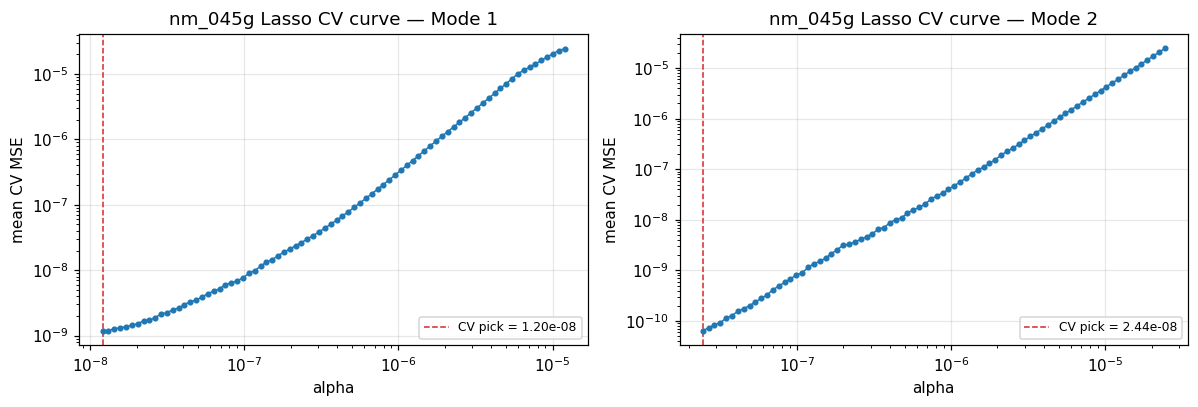


--- Linear coefficients that Lasso put on q1, q2, qd1, qd2 ---
  Mnl1: {'qd1': np.float64(0.13912384649636156), 'qd2': np.float64(0.19057674265695587)}
  Mnl2: {'q1': np.float64(-51231.514781520236), 'q2': np.float64(-839240.525699727), 'qd1': np.float64(-39.73422803346705)}


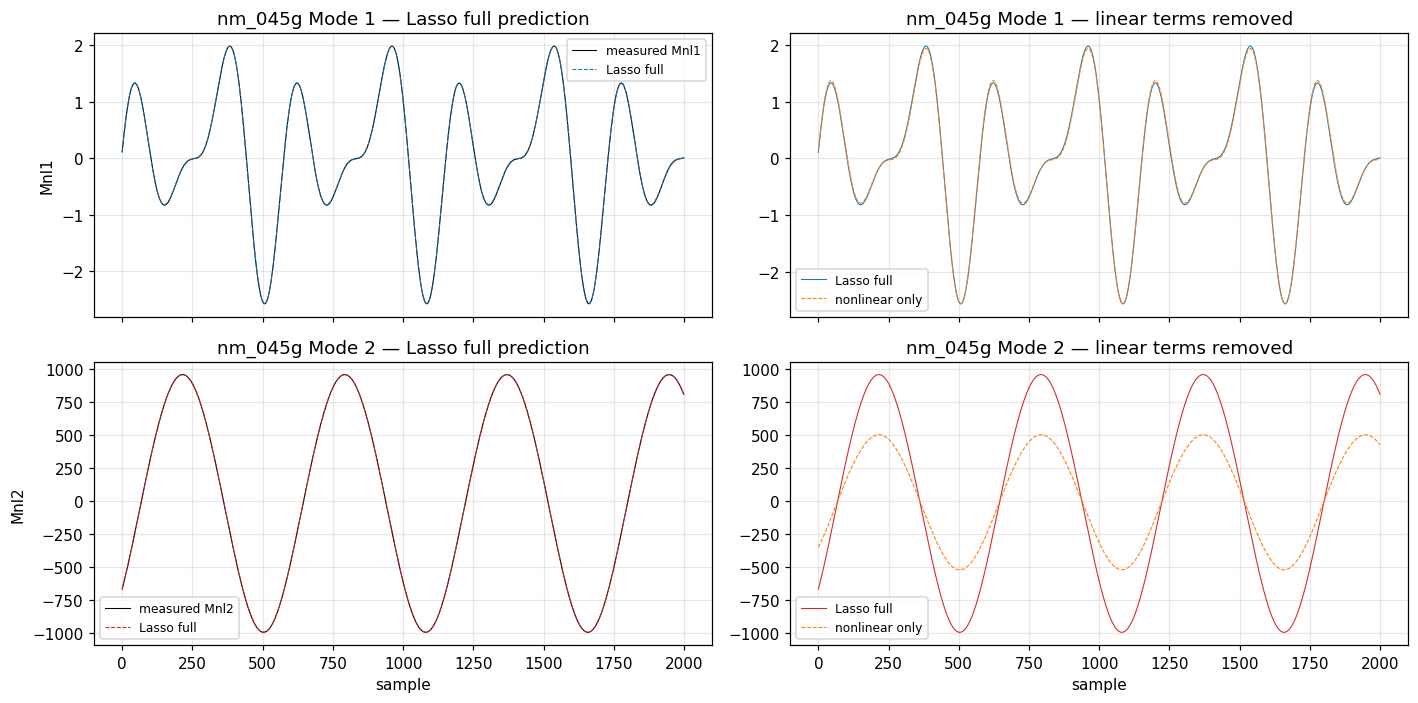


--- STLSQ vs Lasso coefficient comparison (non-zero terms) ---
      term STLSQ_Mnl1 Lasso_Mnl1 STLSQ_Mnl2 Lasso_Mnl2
      q2^3 +0.000e+00 -3.103e+08 +2.180e+11 -1.244e+12
      q1^3 -3.689e+09 -2.021e+09 +0.000e+00 -9.958e+11
   q1 q2^2 -4.828e+10 -2.381e+09 -1.293e+11 -0.000e+00
   q1^2 q2 +1.502e+10 -7.903e+04 +0.000e+00 -0.000e+00
  q2^2 qd1 +0.000e+00 +0.000e+00 +0.000e+00 -4.044e+08
     q1 q2 +3.928e+08 -1.571e+05 +0.000e+00 -0.000e+00
      q1^2 -2.294e+08 -5.748e+05 +0.000e+00 -0.000e+00
      q2^2 -1.094e+08 -3.933e+06 +0.000e+00 -4.260e+07
  q2 qd1^2 +3.811e+04 +2.619e+03 +0.000e+00 -2.932e+07
q2 qd1 qd2 -4.115e+05 +7.746e+03 +0.000e+00 -1.121e+07
  q2 qd2^2 -1.379e+05 +2.518e+04 +0.000e+00 -4.702e+06
 q1 q2 qd1 +0.000e+00 +2.217e+06 +0.000e+00 -0.000e+00
        q2 +0.000e+00 -0.000e+00 -2.002e+06 -8.392e+05
  q2^2 qd2 +0.000e+00 +1.774e+06 +0.000e+00 -0.000e+00
  q1 qd1^2 +0.000e+00 +9.269e+04 +0.000e+00 -0.000e+00
q1 qd1 qd2 +6.004e+04 +0.000e+00 +0.000e+00 -0.000e+00
 

In [15]:
# =============================================================================
#  Lasso identification (LassoCV — automatic alpha selection)
#  Drop in after the STLSQ fit. Uses existing:
#     X, Mnl1, Mnl2, names, build_library(), format_equation(),
#     error_metrics(), FEATURE_VARS, TAG, xi1, xi2 (STLSQ fits for comparison)
# =============================================================================
from sklearn.linear_model import LassoCV
from sklearn.exceptions import ConvergenceWarning
import warnings
warnings.filterwarnings('ignore', category=ConvergenceWarning)


def fit_lasso_cv(X, y, lib, cv=5, n_alphas=80, max_iter=30000):
    """LassoCV with the same dual-normalization used for STLSQ."""
    lib.fit(X)
    Theta = np.asarray(lib.transform(X))
    names_ = lib.get_feature_names(FEATURE_VARS)

    col_scales = np.linalg.norm(Theta, axis=0) + 1e-30
    y_scale    = np.linalg.norm(y) + 1e-30
    Theta_n    = Theta / col_scales
    y_n        = y / y_scale

    cvm = LassoCV(cv=cv, alphas=n_alphas, max_iter=max_iter,
                  fit_intercept=False, random_state=0, n_jobs=-1,
                  selection='random')
    cvm.fit(Theta_n, y_n)

    xi = cvm.coef_ * y_scale / col_scales
    return xi, names_, Theta, cvm.alpha_, cvm


# ---- Fit both modes --------------------------------------------------------
print('=' * 72)
print('Lasso with cross-validated alpha (LassoCV, 5-fold)')
print('=' * 72)

xi1_l, names_l, Theta1_l, alpha1_cv, cvm1 = fit_lasso_cv(X, Mnl1, build_library())
xi2_l, _,       Theta2_l, alpha2_cv, cvm2 = fit_lasso_cv(X, Mnl2, build_library())

Mnl1_hat_l = Theta1_l @ xi1_l
Mnl2_hat_l = Theta2_l @ xi2_l
err1_l = error_metrics(Mnl1, Mnl1_hat_l)
err2_l = error_metrics(Mnl2, Mnl2_hat_l)

print(f'\n=== Mode 1 — alpha_cv = {alpha1_cv:.3e}   '
      f'({int(np.sum(np.abs(xi1_l) > 0))} terms) ===')
print(format_equation(xi1_l, names_l, lhs='Mnl1'))
print(f'  RMSE = {err1_l["RMSE"]:.3e},  R2 = {err1_l["R2"]:+.6f},  '
      f'MAE = {err1_l["MAE"]:.3e}')

print(f'\n=== Mode 2 — alpha_cv = {alpha2_cv:.3e}   '
      f'({int(np.sum(np.abs(xi2_l) > 0))} terms) ===')
print(format_equation(xi2_l, names_l, lhs='Mnl2'))
print(f'  RMSE = {err2_l["RMSE"]:.3e},  R2 = {err2_l["R2"]:+.6f},  '
      f'MAE = {err2_l["MAE"]:.3e}')


# ---- CV curves (diagnostic: how confident is the alpha pick?) --------------
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for a_ax, cvm, alpha_cv, title in [(ax[0], cvm1, alpha1_cv, 'Mode 1'),
                                   (ax[1], cvm2, alpha2_cv, 'Mode 2')]:
    mse_mean = cvm.mse_path_.mean(axis=1)
    mse_std  = cvm.mse_path_.std(axis=1)
    a_ax.errorbar(cvm.alphas_, mse_mean, yerr=mse_std, fmt='o-', lw=1, ms=3)
    a_ax.axvline(alpha_cv, color='C3', ls='--', lw=1, label=f'CV pick = {alpha_cv:.2e}')
    a_ax.set_xscale('log'); a_ax.set_yscale('log')
    a_ax.set_xlabel('alpha'); a_ax.set_ylabel('mean CV MSE')
    a_ax.set_title(f'{TAG} Lasso CV curve — {title}')
    a_ax.legend(fontsize=8); a_ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


# ---- Strip linear terms ----------------------------------------------------
LINEAR_TERMS = {'q1', 'q2', 'qd1', 'qd2'}

def split_linear_nonlinear(xi, nm, Theta_):
    xi_lin = np.array([c if n in LINEAR_TERMS else 0.0 for c, n in zip(xi, nm)])
    xi_nl  = np.array([0.0 if n in LINEAR_TERMS else c for c, n in zip(xi, nm)])
    return Theta_ @ xi_lin, Theta_ @ xi_nl

Mnl1_lin_l, Mnl1_nl_l = split_linear_nonlinear(xi1_l, names_l, Theta1_l)
Mnl2_lin_l, Mnl2_nl_l = split_linear_nonlinear(xi2_l, names_l, Theta2_l)

print('\n--- Linear coefficients that Lasso put on q1, q2, qd1, qd2 ---')
for lbl, xi in [('Mnl1', xi1_l), ('Mnl2', xi2_l)]:
    lin = {n: c for c, n in zip(xi, names_l) if n in LINEAR_TERMS and abs(c) > 0}
    print(f'  {lbl}: {lin if lin else "(none)"}')


# ---- Before vs after removing linear terms (4 panels) ----------------------
n_show = 2000
fig, ax = plt.subplots(2, 2, figsize=(13, 6.5), sharex=True)

# Mode 1: left = measured vs full Lasso fit, right = full vs nonlinear-only
ax[0, 0].plot(Mnl1[:n_show],        lw=0.7, color='k', label='measured Mnl1')
ax[0, 0].plot(Mnl1_hat_l[:n_show],  lw=0.7, ls='--', color='C0', label='Lasso full')
ax[0, 0].set_ylabel('Mnl1'); ax[0, 0].grid(alpha=0.3)
ax[0, 0].set_title(f'{TAG} Mode 1 — Lasso full prediction'); ax[0, 0].legend(fontsize=8)

ax[0, 1].plot(Mnl1_hat_l[:n_show],  lw=0.7, color='C0', label='Lasso full')
ax[0, 1].plot(Mnl1_nl_l[:n_show],   lw=0.7, ls='--', color='C1', label='nonlinear only')
ax[0, 1].set_title(f'{TAG} Mode 1 — linear terms removed')
ax[0, 1].grid(alpha=0.3); ax[0, 1].legend(fontsize=8)

# Mode 2
ax[1, 0].plot(Mnl2[:n_show],        lw=0.7, color='k', label='measured Mnl2')
ax[1, 0].plot(Mnl2_hat_l[:n_show],  lw=0.7, ls='--', color='C3', label='Lasso full')
ax[1, 0].set_ylabel('Mnl2'); ax[1, 0].set_xlabel('sample'); ax[1, 0].grid(alpha=0.3)
ax[1, 0].set_title(f'{TAG} Mode 2 — Lasso full prediction'); ax[1, 0].legend(fontsize=8)

ax[1, 1].plot(Mnl2_hat_l[:n_show],  lw=0.7, color='C3', label='Lasso full')
ax[1, 1].plot(Mnl2_nl_l[:n_show],   lw=0.7, ls='--', color='C1', label='nonlinear only')
ax[1, 1].set_title(f'{TAG} Mode 2 — linear terms removed')
ax[1, 1].set_xlabel('sample'); ax[1, 1].grid(alpha=0.3); ax[1, 1].legend(fontsize=8)
plt.tight_layout(); plt.show()


# ---- STLSQ vs Lasso coefficient comparison ---------------------------------
compare_df = pd.DataFrame({
    'term': names_l,
    'STLSQ_Mnl1': xi1,          # from your earlier STLSQ fit
    'Lasso_Mnl1': xi1_l,
    'STLSQ_Mnl2': xi2,
    'Lasso_Mnl2': xi2_l,
})
mask = (compare_df[['STLSQ_Mnl1', 'Lasso_Mnl1',
                    'STLSQ_Mnl2', 'Lasso_Mnl2']].abs() > 0).any(axis=1)
compare_df = compare_df[mask].copy()
compare_df = compare_df.reindex(
    compare_df[['STLSQ_Mnl1', 'Lasso_Mnl1',
                'STLSQ_Mnl2', 'Lasso_Mnl2']].abs().max(axis=1)
    .sort_values(ascending=False).index
).reset_index(drop=True)

print('\n--- STLSQ vs Lasso coefficient comparison (non-zero terms) ---')
print(compare_df.to_string(index=False,
      formatters={c: '{:+.3e}'.format for c in compare_df.columns[1:]}))

# Summary metrics side by side
summary = pd.DataFrame({
    'method': ['STLSQ', 'Lasso'],
    'Mnl1_n_terms': [int(np.sum(np.abs(xi1) > 0)), int(np.sum(np.abs(xi1_l) > 0))],
    'Mnl1_RMSE':    [err1['RMSE'],  err1_l['RMSE']],
    'Mnl1_R2':      [err1['R2'],    err1_l['R2']],
    'Mnl2_n_terms': [int(np.sum(np.abs(xi2) > 0)), int(np.sum(np.abs(xi2_l) > 0))],
    'Mnl2_RMSE':    [err2['RMSE'],  err2_l['RMSE']],
    'Mnl2_R2':      [err2['R2'],    err2_l['R2']],
})
print('\n--- Summary ---')
print(summary.to_string(index=False,
      formatters={'Mnl1_RMSE':'{:.3e}'.format, 'Mnl2_RMSE':'{:.3e}'.format,
                  'Mnl1_R2':'{:+.6f}'.format,  'Mnl2_R2':'{:+.6f}'.format}))

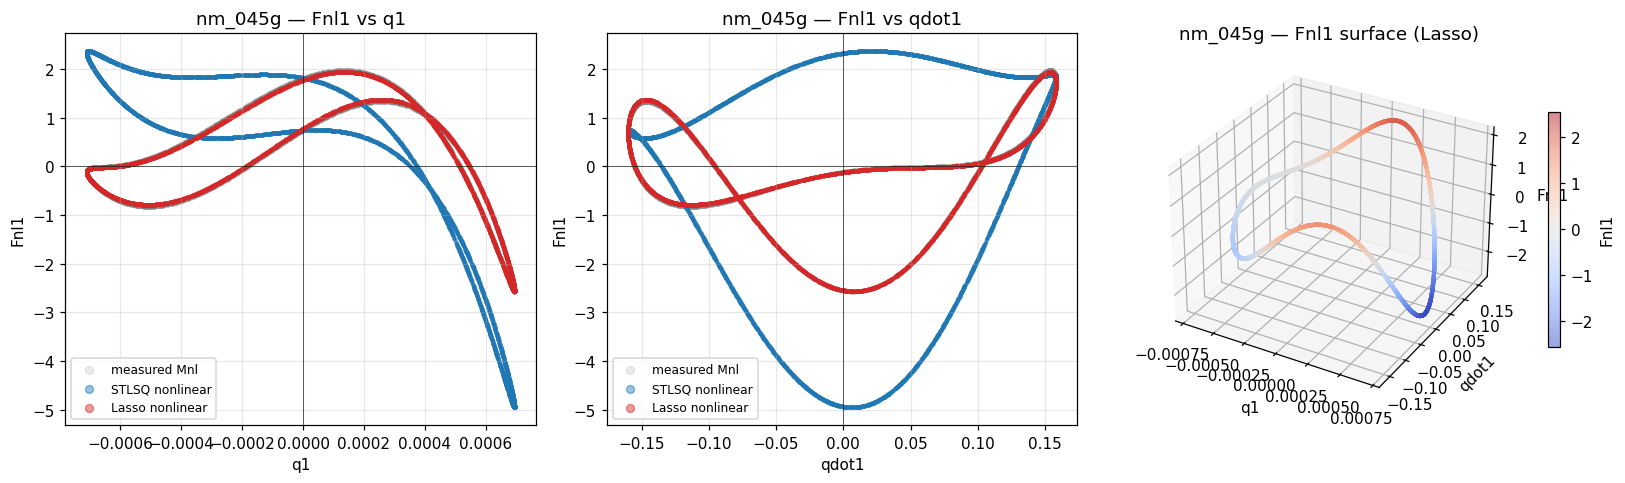

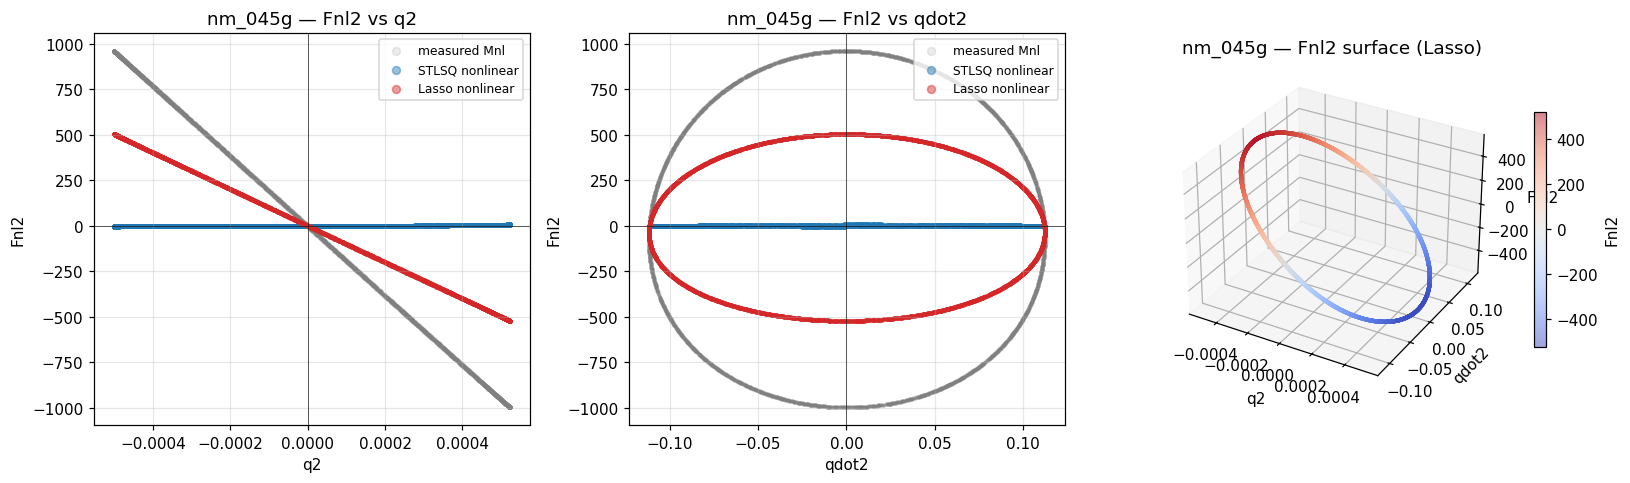

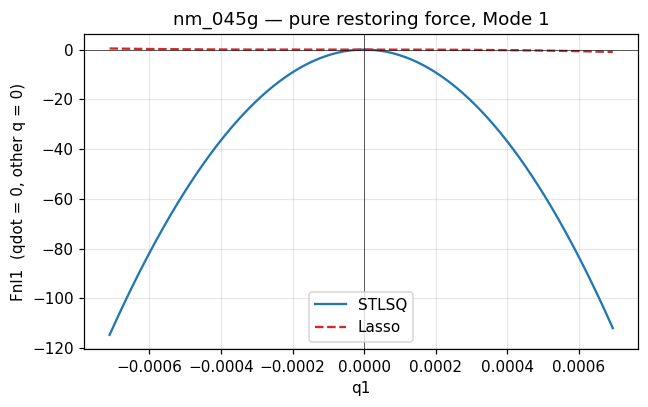

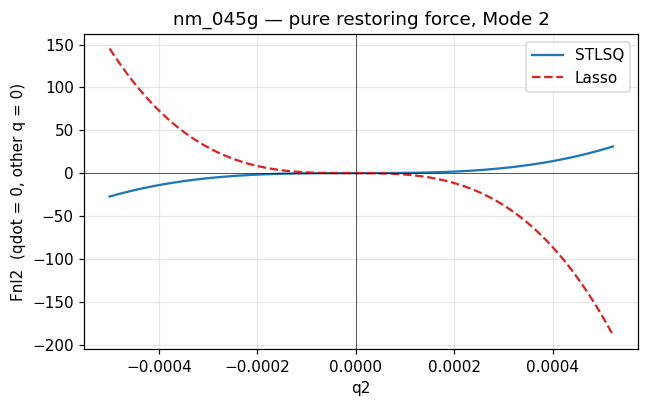

In [16]:
# =============================================================================
#  Fnl vs q, Fnl vs qdot, Fnl surface over (q, qdot)
#  Compares STLSQ and Lasso side by side, both with linear terms removed.
#  Uses: q1, q2, qd1, qd2, Mnl1, Mnl2,
#        Mnl1_nl_pred/Mnl2_nl_pred  (from the earlier STLSQ linear-strip cell)
#        Mnl1_nl_l/Mnl2_nl_l        (from the Lasso linear-strip cell)
# =============================================================================
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 — registers 3d projection


def plot_fnl_triptych(fnl_s, fnl_l, q, qd, Mnl_measured,
                      mode_label, tag=TAG, n_sub=6000):
    """Three columns: Fnl vs q, Fnl vs qdot, Fnl surface over (q, qdot).
    Two methods overlaid (STLSQ in blue, Lasso in red)."""
    # Sub-sample so the scatter is readable (40k points makes everything black)
    if len(q) > n_sub:
        idx = np.random.default_rng(0).choice(len(q), n_sub, replace=False)
    else:
        idx = np.arange(len(q))
    q_s, qd_s = q[idx], qd[idx]
    fs_s, fl_s = fnl_s[idx], fnl_l[idx]
    mm_s = Mnl_measured[idx]

    fig = plt.figure(figsize=(15, 4.5))

    # (a) Fnl vs q
    ax1 = fig.add_subplot(1, 3, 1)
    ax1.scatter(q_s, mm_s, s=3, alpha=0.15, color='gray', label='measured Mnl')
    ax1.scatter(q_s, fs_s, s=3, alpha=0.45, color='C0',  label='STLSQ nonlinear')
    ax1.scatter(q_s, fl_s, s=3, alpha=0.45, color='C3',  label='Lasso nonlinear')
    ax1.axhline(0, color='k', lw=0.4); ax1.axvline(0, color='k', lw=0.4)
    ax1.set_xlabel(f'q{mode_label}'); ax1.set_ylabel(f'Fnl{mode_label}')
    ax1.set_title(f'{tag} — Fnl{mode_label} vs q{mode_label}')
    ax1.legend(fontsize=8, markerscale=3); ax1.grid(alpha=0.3)

    # (b) Fnl vs qdot
    ax2 = fig.add_subplot(1, 3, 2)
    ax2.scatter(qd_s, mm_s, s=3, alpha=0.15, color='gray', label='measured Mnl')
    ax2.scatter(qd_s, fs_s, s=3, alpha=0.45, color='C0',  label='STLSQ nonlinear')
    ax2.scatter(qd_s, fl_s, s=3, alpha=0.45, color='C3',  label='Lasso nonlinear')
    ax2.axhline(0, color='k', lw=0.4); ax2.axvline(0, color='k', lw=0.4)
    ax2.set_xlabel(f'qdot{mode_label}'); ax2.set_ylabel(f'Fnl{mode_label}')
    ax2.set_title(f'{tag} — Fnl{mode_label} vs qdot{mode_label}')
    ax2.legend(fontsize=8, markerscale=3); ax2.grid(alpha=0.3)

    # (c) Fnl surface over (q, qdot) — use Lasso (cleaner visualization)
    ax3 = fig.add_subplot(1, 3, 3, projection='3d')
    sc = ax3.scatter(q_s, qd_s, fl_s, c=fl_s, s=3, alpha=0.5, cmap='coolwarm',
                     vmin=-np.max(np.abs(fl_s)), vmax=+np.max(np.abs(fl_s)))
    ax3.set_xlabel(f'q{mode_label}'); ax3.set_ylabel(f'qdot{mode_label}')
    ax3.set_zlabel(f'Fnl{mode_label}')
    ax3.set_title(f'{tag} — Fnl{mode_label} surface (Lasso)')
    fig.colorbar(sc, ax=ax3, shrink=0.6, pad=0.08, label=f'Fnl{mode_label}')

    plt.tight_layout(); plt.show()


plot_fnl_triptych(Mnl1_nl_pred, Mnl1_nl_l, q1, qd1, Mnl1, mode_label='1')
plot_fnl_triptych(Mnl2_nl_pred, Mnl2_nl_l, q2, qd2, Mnl2, mode_label='2')


# =============================================================================
#  Optional: clean analytic curves on the Fnl-vs-q plot.
#  Projects the full model onto the 1D slice qdot=0, q_other=0, so you see
#  the pure restoring-force shape without scatter from the other variables.
# =============================================================================
def evaluate_on_slice(xi, names_, slice_vars):
    """Evaluate model on a 1D grid where only one variable varies.
    slice_vars: dict mapping var name to either a scalar or a 1D array.
    Exactly one entry should be a 1D array — that's the axis."""
    # Find the varying axis
    axis_name = [k for k, v in slice_vars.items()
                 if hasattr(v, '__len__')][0]
    axis_vals = slice_vars[axis_name]
    n = len(axis_vals)

    X_slice = np.zeros((n, 4))
    for j, var in enumerate(FEATURE_VARS):
        if var == axis_name:
            X_slice[:, j] = axis_vals
        else:
            X_slice[:, j] = slice_vars[var]

    lib = build_library()
    lib.fit(X_slice)
    Theta_slice = np.asarray(lib.transform(X_slice))
    # Zero out linear columns so we see only nonlinear contribution
    xi_nl = np.array([0.0 if n_ in {'q1','q2','qd1','qd2'} else c
                      for c, n_ in zip(xi, names_)])
    return Theta_slice @ xi_nl


def plot_restoring_curve(xi_s, xi_l, names_, mode_label, q_range, tag=TAG):
    """Clean Fnl(q) curve with qdot=0, other q=0, from each identified model."""
    q_grid = np.linspace(q_range[0], q_range[1], 400)
    q_key  = f'q{mode_label}'
    slice_zero = {k: 0.0 for k in FEATURE_VARS}
    slice_zero[q_key] = q_grid

    fnl_s = evaluate_on_slice(xi_s, names_, slice_zero)
    fnl_l = evaluate_on_slice(xi_l, names_, slice_zero)

    fig, ax = plt.subplots(figsize=(6, 3.8))
    ax.plot(q_grid, fnl_s, color='C0', lw=1.5, label='STLSQ')
    ax.plot(q_grid, fnl_l, color='C3', lw=1.5, ls='--', label='Lasso')
    ax.axhline(0, color='k', lw=0.4); ax.axvline(0, color='k', lw=0.4)
    ax.set_xlabel(f'q{mode_label}')
    ax.set_ylabel(f'Fnl{mode_label}  (qdot = 0, other q = 0)')
    ax.set_title(f'{tag} — pure restoring force, Mode {mode_label}')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()


plot_restoring_curve(xi1, xi1_l, names_l, mode_label='1',
                     q_range=(q1.min(), q1.max()))
plot_restoring_curve(xi2, xi2_l, names_l, mode_label='2',
                     q_range=(q2.min(), q2.max()))